
# Solving Blackjack with Tabular Q-Learning

**Blackjack** is one of the most popular casino card games that is also
infamous for being beatable under certain conditions. This version of
the game uses an infinite deck (we draw the cards with replacement), so
counting cards won’t be a viable strategy in our simulated game.

**Objective**: To win, your card sum should be greater than the
dealers without exceeding 21.

**Actions**: Agents can pick between two actions:
 - stand (0): the player takes no more cards
 - hit (1): the player will be given another card, however the player could get over 21 and bust

**Approach**: In this solution, we explore the Tabular Q-Learning algorithm.  
**Documentation**: The full documentation used to take inspiration for this code, and the whole project is available in the Gymnasium official website.

# Imports and Environment Setup




In [ ]:
# student's matricola number

# Mattia Raffaele Ricciardelli: 1983489
# Camille Justine Gomez Eugenio: 2216495

from __future__ import annotations

from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Patch
from tqdm import tqdm

import gymnasium as gym


# Let's start by creating the blackjack environment (We are going to follow the rules from Sutton & Barto)

env = gym.make("Blackjack-v1", sab=True)

In [ ]:
env.close()

# Building The Blackjack Q-Learning Agent

We initialize the Blackjack Q-Learning agent with the following args:
* `env`: The training environment
* `learning_rate`: How quickly to update Q-values (0-1)
* `initial_epsilon`: Starting exploration rate (usually 1.0)
* `epsilon_decay`: How much to reduce epsilon each episode
* `final_epsilon`: Minimum exploration rate (usually 0.1)
* `discount_factor`: How much to value future rewards (0-1)

To build the agent we will need some functions for picking an action and updating the agents action values.  
To ensure that the agents explores the environment, one possible
solution is the ``epsilon-greedy`` strategy, where we pick a random
action with the percentage ``epsilon`` and the greedy action (currently
valued as the best) ``1 - epsilon``.



In [ ]:
class BlackjackAgent:
    def __init__(
        self,
        env,
        learning_rate: float,
        initial_epsilon: float,
        epsilon_decay: float,
        final_epsilon: float,
        discount_factor: float = 0.95,
    ):
        """Initialize a Reinforcement Learning agent with an empty dictionary
        of state-action values (q_values), a learning rate and an epsilon.

        Args:
            learning_rate: The learning rate
            initial_epsilon: The initial epsilon value
            epsilon_decay: The decay for epsilon
            final_epsilon: The final epsilon value
            discount_factor: The discount factor for computing the Q-value
        """
        self.q_values = defaultdict(lambda: np.zeros(env.action_space.n))

        self.lr = learning_rate
        self.discount_factor = discount_factor

        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon

        self.training_error = []

    def get_action(self, env, obs: tuple[int, int, bool]) -> int:
        """
        Returns the best action with probability (1 - epsilon)
        otherwise a random action with probability epsilon to ensure exploration.
        """
        # with probability epsilon return a random action to explore the environment
        if np.random.random() < self.epsilon:
            return env.action_space.sample()

        # with probability (1 - epsilon) act greedily (exploit)
        else:
            return int(np.argmax(self.q_values[obs]))

    def update(
        self,
        obs: tuple[int, int, bool],
        action: int,
        reward: float,
        terminated: bool,
        next_obs: tuple[int, int, bool],
    ):
        """Updates the Q-value of an action."""
        future_q_value = (not terminated) * np.max(self.q_values[next_obs])
        temporal_difference = (
            reward + self.discount_factor * future_q_value - self.q_values[obs][action]
        )

        self.q_values[obs][action] = (
            self.q_values[obs][action] + self.lr * temporal_difference
        )
        self.training_error.append(temporal_difference)

    def decay_epsilon(self):
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)

To train the agent, we will let the agent play one episode (one complete
game) at a time and then update it’s Q-values after
each step (one single action).

The agent will have to experience a lot of episodes to explore the
environment sufficiently.

In [ ]:
# hyperparameters
learning_rate = 0.005
n_episodes = 500_000_0
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)  # reduce the exploration over time
final_epsilon = 0.1

agent = BlackjackAgent(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

# Training Loop

To train the agent the process includes:

1.  **Reset environment** to start a new episode
2.   **Play one complete hand** (episode), choosing actions and learning from each step
3. **Update exploration rate** (reduce epsilon)
4. **Repeat** for many episodes until the agent learns good strategy






We call ``env.reset()`` to start an episode. This function
resets the environment to a starting position and returns an initial
``observation``. We usually also set ``done = False``. This variable
will be useful later to check if a game is terminated (i.e., the player wins or loses).

In [ ]:
# List to store epsilon values
epsilon_values = []
episode_rewards = []

for episode in tqdm(range(1, n_episodes + 1), desc="Training"):
    obs, info = env.reset()
    done = False
    total_reward = 0

    # Store the current epsilon value at the beginning of the episode
    epsilon_values.append(agent.epsilon)

    if episode % 100000 == 0:
        perc = int((episode / n_episodes) * 100)
        print(f"| EP {episode} | Epsilon: {agent.epsilon:.4f}")

    # Play one episode
    while not done:
        action = agent.get_action(env, obs) # Select action using epsilon-greedy strategy
        next_obs, reward, terminated, truncated, info = env.step(action)

        # Update the agent
        agent.update(obs, action, reward, terminated, next_obs)

        # Update if the environment is done and the current observation
        done = terminated or truncated
        obs = next_obs

        # Accumulate total reward for the episode
        total_reward += reward

    # Decay epsilon after the episode
    agent.decay_epsilon()
    episode_rewards.append(total_reward) # Store total reward for the episode

print("\n Training Complete.")

Training:   2%|▏         | 100226/5000000 [00:18<20:22, 4008.45it/s]

| EP 100000 | Epsilon: 0.1000


Training:   4%|▍         | 201109/5000000 [00:38<11:55, 6708.70it/s]

| EP 200000 | Epsilon: 0.1000


Training:   6%|▌         | 300827/5000000 [00:54<11:46, 6653.47it/s]

...

| EP 4800000 | Epsilon: 0.1000


Training:  98%|█████████▊| 4900728/5000000 [13:55<00:14, 6666.17it/s]

| EP 4900000 | Epsilon: 0.1000


Training: 100%|██████████| 5000000/5000000 [14:12<00:00, 5864.35it/s]

| EP 5000000 | Epsilon: 0.1000

 Training Complete.


# Analyzing Training Results

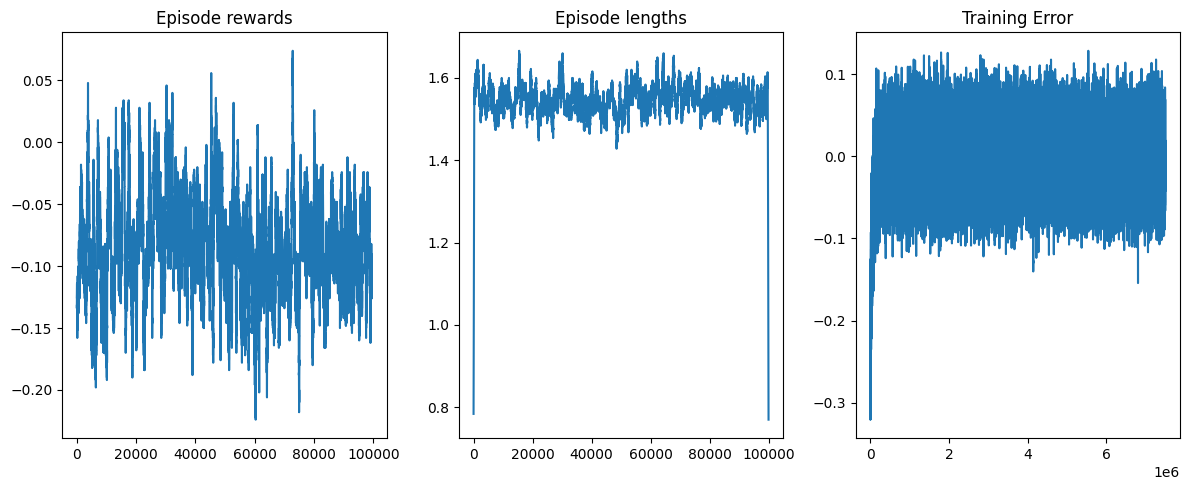

In [ ]:
rolling_length = 500
fig, axs = plt.subplots(ncols=3, figsize=(12, 5))
axs[0].set_title("Episode rewards")
# compute and assign a rolling average of the data to provide a smoother graph
reward_moving_average = (
    np.convolve(
        np.array(env.return_queue).flatten(), np.ones(rolling_length), mode="valid"
    )
    / rolling_length
)
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)
axs[1].set_title("Episode lengths")
length_moving_average = (
    np.convolve(
        np.array(env.length_queue).flatten(), np.ones(rolling_length), mode="same"
    )
    / rolling_length
)
axs[1].plot(range(len(length_moving_average)), length_moving_average)
axs[2].set_title("Training Error")
training_error_moving_average = (
    np.convolve(np.array(agent.training_error), np.ones(rolling_length), mode="same")
    / rolling_length
)
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
plt.tight_layout()
plt.show()

# Performance Visualization
In this section we explore:
1. A graph showing how the agent's average reward evolves over time;
2. A graph of how the exploration rate (espilon) decreases across episodes;

In [ ]:
def plot_learning_diagnostics(episode_rewards, epsilon_values=None, window_size=1000):
    # 1. Average Reward Over Time
    rewards = np.array(episode_rewards)
    x = np.arange(len(rewards))
    rolling_avg = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')

    plt.figure(figsize=(12, 5))
    plt.plot(x[window_size-1:], rolling_avg, label=f"Moving Average ({window_size} episodes)", color='royalblue')
    plt.axhline(y=0, color='lightgray', linestyle='--', label='Draw (reward = 0)')
    plt.title("Average Reward Over Time", fontsize=14)
    plt.xlabel("Episodes", fontsize=12)
    plt.ylabel("Average Reward", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\n" * 2)

    # 2. Epsilon Over Time
    if epsilon_values is not None:
      plt.figure(figsize=(12, 4))
      plt.plot(epsilon_values, color='coral')  # Changed color for better visibility
      plt.title("Epsilon Over Time", fontsize=14)
      plt.xlabel("Episodes", fontsize=12)
      plt.ylabel("Epsilon Value", fontsize=12)
      plt.grid(True, linestyle='--', alpha=0.4)
      plt.tight_layout()
      plt.show()

    print("\n" * 2)

/tmp/ipython-input-27-1063602943.py:15: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


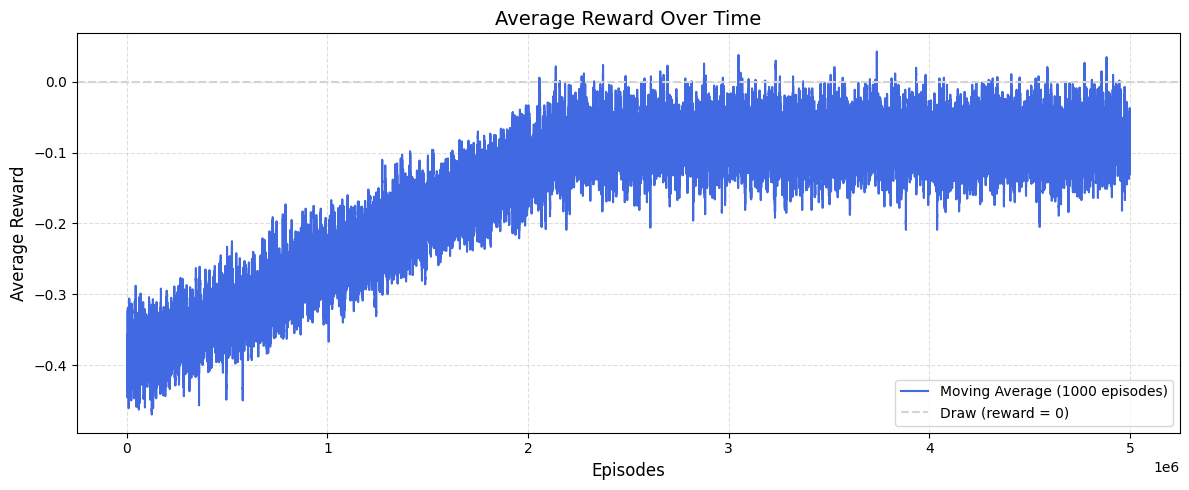

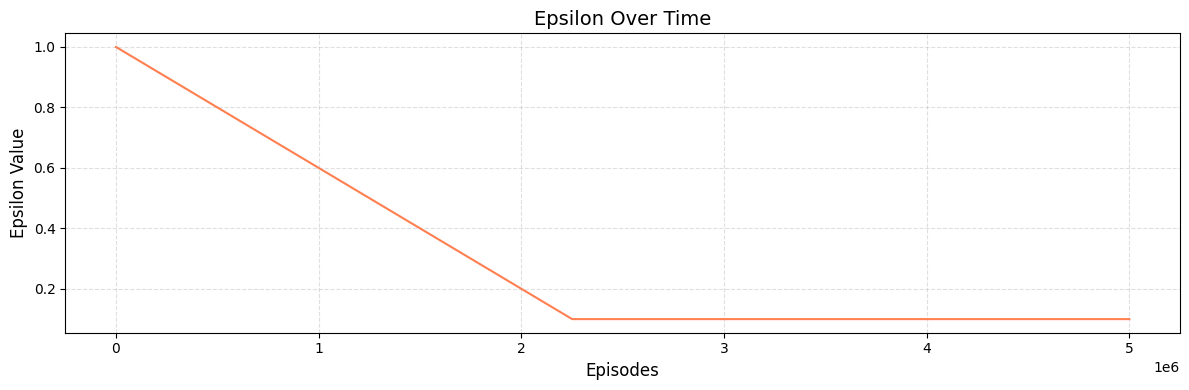

In [ ]:
plot_learning_diagnostics(
    episode_rewards=episode_rewards,
    epsilon_values=epsilon_values,
    window_size=1000
)

# Visualising the policy
The plots show the learned policies, comparing the Agent's decision depending on whether it holds a usable ace or not.



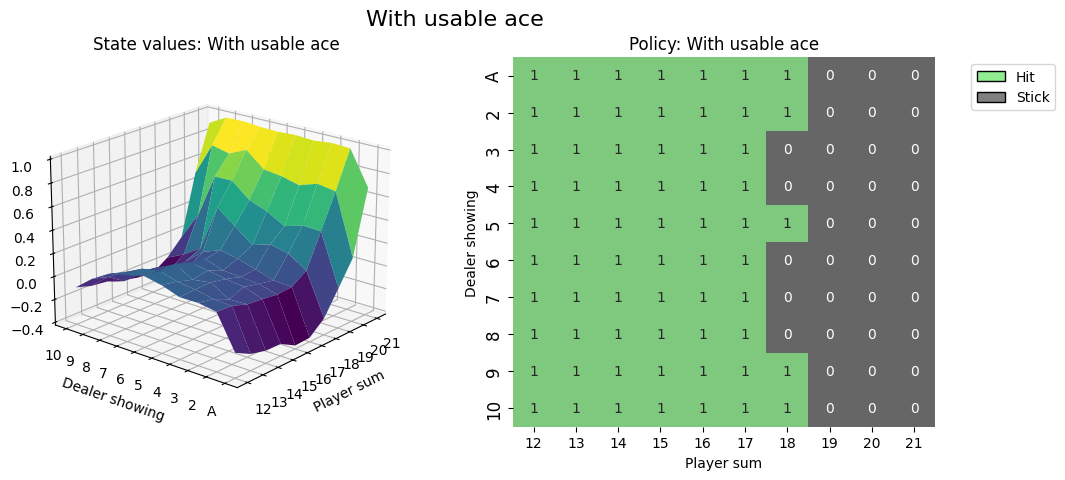

In [ ]:
def create_grids(agent, usable_ace=False):
    """Create value and policy grid given an agent."""
    # convert our state-action values to state values
    # and build a policy dictionary that maps observations to actions
    state_value = defaultdict(float)
    policy = defaultdict(int)
    for obs, action_values in agent.q_values.items():
        state_value[obs] = float(np.max(action_values))
        policy[obs] = int(np.argmax(action_values))

    player_count, dealer_count = np.meshgrid(
        # players count, dealers face-up card
        np.arange(12, 22),
        np.arange(1, 11),
    )

    # create the value grid for plotting
    value = np.apply_along_axis(
        lambda obs: state_value[(obs[0], obs[1], usable_ace)],
        axis=2,
        arr=np.dstack([player_count, dealer_count]),
    )
    value_grid = player_count, dealer_count, value

    # create the policy grid for plotting
    policy_grid = np.apply_along_axis(
        lambda obs: policy[(obs[0], obs[1], usable_ace)],
        axis=2,
        arr=np.dstack([player_count, dealer_count]),
    )
    return value_grid, policy_grid


def create_plots(value_grid, policy_grid, title: str):
    """Creates a plot using a value and policy grid."""
    # create a new figure with 2 subplots (left: state values, right: policy)
    player_count, dealer_count, value = value_grid
    fig = plt.figure(figsize=plt.figaspect(0.4))
    fig.suptitle(title, fontsize=16)

    # plot the state values
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.plot_surface(
        player_count,
        dealer_count,
        value,
        rstride=1,
        cstride=1,
        cmap="viridis",
        edgecolor="none",
    )
    plt.xticks(range(12, 22), range(12, 22))
    plt.yticks(range(1, 11), ["A"] + list(range(2, 11)))
    ax1.set_title(f"State values: {title}")
    ax1.set_xlabel("Player sum")
    ax1.set_ylabel("Dealer showing")
    ax1.zaxis.set_rotate_label(False)
    ax1.set_zlabel("Value", fontsize=14, rotation=90)
    ax1.view_init(20, 220)

    # plot the policy
    fig.add_subplot(1, 2, 2)
    ax2 = sns.heatmap(policy_grid, linewidth=0, annot=True, cmap="Accent_r", cbar=False)
    ax2.set_title(f"Policy: {title}")
    ax2.set_xlabel("Player sum")
    ax2.set_ylabel("Dealer showing")
    ax2.set_xticklabels(range(12, 22))
    ax2.set_yticklabels(["A"] + list(range(2, 11)), fontsize=12)

    # add a legend
    legend_elements = [
        Patch(facecolor="lightgreen", edgecolor="black", label="Hit"),
        Patch(facecolor="grey", edgecolor="black", label="Stick"),
    ]
    ax2.legend(handles=legend_elements, bbox_to_anchor=(1.3, 1))
    return fig


# state values & policy with usable ace (ace counts as 11)
value_grid, policy_grid = create_grids(agent, usable_ace=True)
fig1 = create_plots(value_grid, policy_grid, title="With usable ace")
plt.show()

<img src="file://_static/img/tutorials/blackjack_with_usable_ace.png">




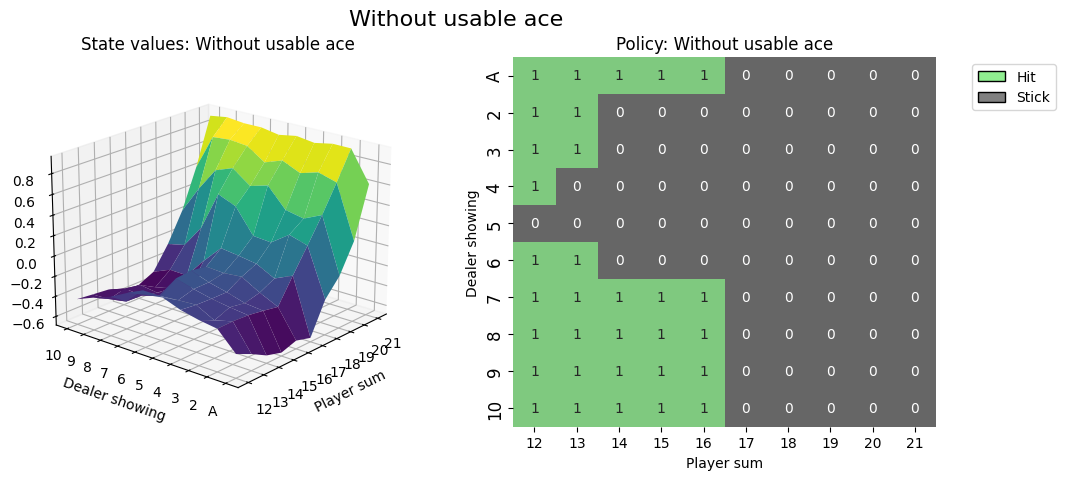

In [ ]:
# state values & policy without usable ace (ace counts as 1)
value_grid, policy_grid = create_grids(agent, usable_ace=False)
fig2 = create_plots(value_grid, policy_grid, title="Without usable ace")
plt.show()

# Test and Evaluation
The performance of the Agent is assessed in terms of:
- win rate: ideally between 43%-48%
- average reward: ideally ranging between -0.02 to +0.01
- consistency: low standard deviation indicates reliable strategy

Testing Epsilon-Greedy Policy: 100%|██████████| 10000/10000 [00:01<00:00, 7638.21it/s]



RESULTS
Wins       : 4356 (43.56%)
Draws      : 885 (8.85%)
Losses     : 4759 (47.59%)
Average Reward: -0.040
Consistency (Standard Deviation): 0.954


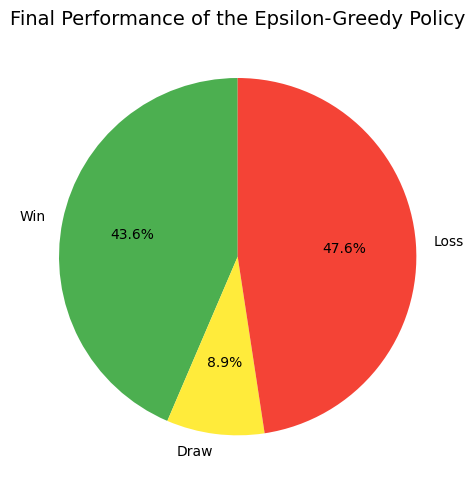

In [ ]:
# Initialize counters for results
wins = draws = losses = 0
total_reward = 0
test_episodes = 10000
episode_rewards = []

# Testing the greedy policy
for _ in tqdm(range(test_episodes), desc="Testing Epsilon-Greedy Policy"):
    state, _ = env.reset()
    done = False
    reward_per_episode = 0


    while not done:
        action = int(np.argmax(agent.q_values[state]))  # Choose the best action based on Q-values
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        state = next_state
        total_reward += reward  # Accumulate total reward
        reward_per_episode += reward  # Accumulate reward for the episode

    episode_rewards.append(reward_per_episode)


    # Count the results
    if reward > 0:
        wins += 1
    elif reward == 0:
        draws += 1
    else:
        losses += 1

# Calculate evaluation metrics
win_rate = wins / test_episodes
average_reward = total_reward / test_episodes
consistency = np.std(episode_rewards)  # Standard deviation of rewards

# Print results
print("\nRESULTS")
print(f"Wins       : {wins} ({win_rate:.2%})")
print(f"Draws      : {draws} ({draws/test_episodes:.2%})")
print(f"Losses     : {losses} ({losses/test_episodes:.2%})")
print(f"Average Reward: {average_reward:.3f}")
print(f"Consistency (Standard Deviation): {consistency:.3f}")

# Prepare data for pie chart
test_results = (wins, draws, losses)
labels = ['Win', 'Draw', 'Loss']
sizes = [wins, draws, losses]
colors = ['#4CAF50', '#FFEB3B', '#F44336']

# Create pie chart
plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title("Final Performance of the Epsilon-Greedy Policy", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
env.close()

# Trying a different strategy
Instead of using the classic **ε-greedy strategy**, we now test the **two-phase decaying ε-greedy**.  

The main difference is that ε first decreases linearly until it reaches a midpoint, allowing for significant exploration in the early episodes. Then after reaching the midpoint, ε decreases exponentially towards the minimum value, reducing exploration as the agent becomes more confident in its learned strategies.

In summary, the **two-phase decaying ε-greedy strategy** provides a more dynamic and adaptable approach to learning, enhancing the agent's effectiveness over time.

## Q-Learning Agent: variant
We definte the `get_epsilon` function, that calculates the exploration rate for the current episode, using the strategy described above.



In [ ]:
class BlackjackAgent2:
    def __init__(
        self,
        env,
        learning_rate: float,
        epsilon_start: float,
        epsilon_min: float,
        discount_factor: float = 0.95,
        num_episodes = int
    ):
        """Initialize a Reinforcement Learning agent with an empty dictionary
        of state-action values (q_values), a learning rate and an epsilon.

        Args:
            learning_rate: The learning rate
            initial_epsilon: The initial epsilon value
            epsilon_decay: The decay for epsilon
            final_epsilon: The final epsilon value
            discount_factor: The discount factor for computing the Q-value
        """
        self.q_values = defaultdict(lambda: np.zeros(env.action_space.n))

        self.lr = learning_rate
        self.discount_factor = discount_factor

        self.epsilon_start = epsilon_start
        self.epsilon_min = epsilon_min
        self.num_episodes = num_episodes

        self.training_error = []

    def get_epsilon(self, episode: int) -> float:
        """Calculate the exploration rate (epsilon) for the current episode.

        Args:
            episode (int): The current episode number.

        Returns:
            float: The current exploration rate (epsilon).
        """
        decay_ratio = episode / self.num_episodes

        # Value at halfway (end of the first phase), e.g., 0.5
        epsilon_split = 0.5
        transition_point = 0.4

        if decay_ratio < transition_point:
            return self.epsilon_start - (self.epsilon_start - epsilon_split) * (decay_ratio / transition_point)
        else:
            exponent = (decay_ratio - transition_point) * 12  # Adjusts the rapidity after halfway
            return max(self.epsilon_min, epsilon_split * (0.5 ** exponent))

    def get_action(self, env, obs: tuple[int, int, bool], epsilon: float) -> int:
        """
        Returns the best action with probability (1 - epsilon)
        otherwise a random action with probability epsilon to ensure exploration.
        """
        # with probability epsilon return a random action to explore the environment
        if np.random.random() < epsilon:
            return env.action_space.sample()

        # with probability (1 - epsilon) act greedily (exploit)
        else:
            return int(np.argmax(self.q_values[obs]))

    def update(
        self,
        obs: tuple[int, int, bool],
        action: int,
        reward: float,
        terminated: bool,
        next_obs: tuple[int, int, bool],
    ):
        """Updates the Q-value of an action."""
        future_q_value = (not terminated) * np.max(self.q_values[next_obs])
        temporal_difference = (
            reward + self.discount_factor * future_q_value - self.q_values[obs][action]
        )

        self.q_values[obs][action] = (
            self.q_values[obs][action] + self.lr * temporal_difference
        )
        self.training_error.append(temporal_difference)

# Training the Agent
The rest of the code is the same as the code shown for the first strategy

In [ ]:
# hyperparameters
learning_rate = 0.001
n_episodes = 100_000_0
epsilon_start = 1.0
epsilon_min = 0.05            # Minimum exploration rate

agent2 = BlackjackAgent2(
    env=env,
    learning_rate = learning_rate,
    epsilon_start = epsilon_start,
    epsilon_min = epsilon_min,
    num_episodes=n_episodes
)

In [ ]:
# List to store epsilon values
epsilon_values = []
episode_rewards = []
episode_lengths = []

for episode in tqdm(range(1, n_episodes + 1), desc="Training"):
    obs, info = env.reset()
    done = False
    total_reward = 0
    steps = 0  # Counter for the number of steps

    # Store the current epsilon value at the beginning of the episode
    epsilon = agent2.get_epsilon(episode)
    epsilon_values.append(epsilon)

    if episode % 100000 == 0:
        perc = int((episode / n_episodes) * 100)
        print(f"| EP {episode} | Epsilon: {epsilon:.4f}")

    # Play one episode
    while not done:
        action = agent2.get_action(env, obs, epsilon)
        next_obs, reward, terminated, truncated, info = env.step(action)

        # Update the agent
        agent2.update(obs, action, reward, terminated, next_obs)

        # Update if the environment is done and the current observation
        done = terminated or truncated
        obs = next_obs

        total_reward += reward
        steps += 1

    episode_rewards.append(total_reward)
    episode_lengths.append(steps)


Training:  10%|█         | 101238/1000000 [00:15<02:07, 7046.96it/s]

| EP 100000 | Epsilon: 0.8750


Training:  20%|██        | 200769/1000000 [00:30<01:49, 7281.78it/s]

| EP 200000 | Epsilon: 0.7500


Training:  30%|███       | 300719/1000000 [00:45<01:40, 6964.62it/s]

...

| EP 800000 | Epsilon: 0.0500


Training:  90%|█████████ | 901081/1000000 [02:17<00:14, 7039.34it/s]

| EP 900000 | Epsilon: 0.0500


Training: 100%|██████████| 1000000/1000000 [02:33<00:00, 6503.77it/s]

| EP 1000000 | Epsilon: 0.0500


# Analyzing Training Results

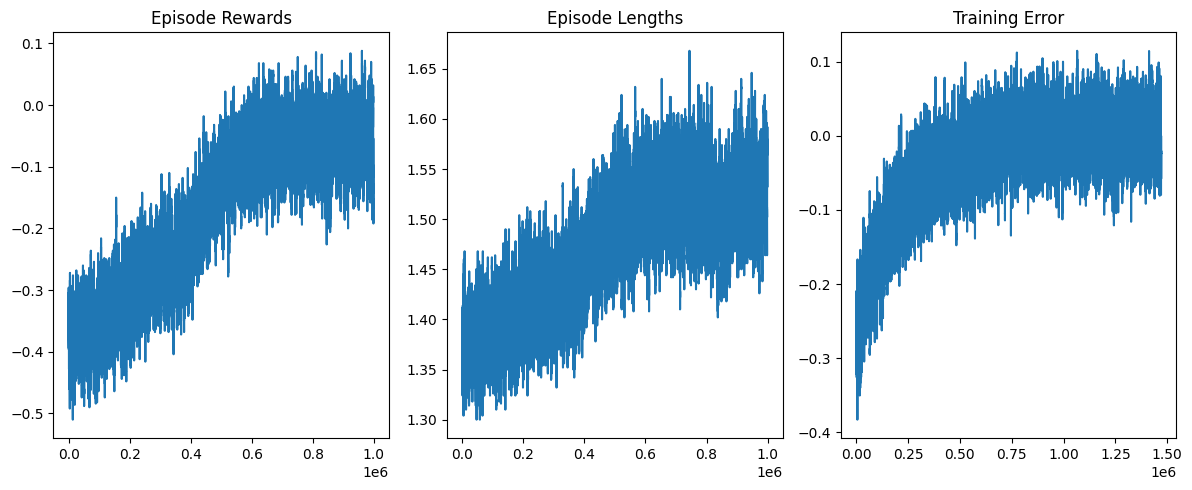

In [ ]:
rolling_length = 500
fig, axs = plt.subplots(ncols=3, figsize=(12, 5))

# Plotting episode rewards
axs[0].set_title("Episode Rewards")
reward_moving_average = (
    np.convolve(
        np.array(episode_rewards), np.ones(rolling_length), mode="valid"
    )
    / rolling_length
)
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)

# Plotting episode lengths
axs[1].set_title("Episode Lengths")
length_moving_average = (
    np.convolve(
        np.array(episode_lengths), np.ones(rolling_length), mode="valid"
    )
    / rolling_length
)
axs[1].plot(range(len(length_moving_average)), length_moving_average)

# Plotting training error
axs[2].set_title("Training Error")
training_error_moving_average = (
    np.convolve(np.array(agent2.training_error), np.ones(rolling_length), mode="valid")
    / rolling_length
)
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
plt.tight_layout()
plt.show()

# Performance Visualization

In [ ]:
def plot_learning_diagnostics(episode_rewards, epsilon_values=None, window_size=1000):
    # 1. Average Reward Over Time
    rewards = np.array(episode_rewards)
    x = np.arange(len(rewards))
    rolling_avg = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')

    plt.figure(figsize=(12, 5))
    plt.plot(x[window_size-1:], rolling_avg, label=f"Moving Average ({window_size} episodes)", color='royalblue')
    plt.axhline(y=0, color='lightgray', linestyle='--', label='Draw (reward = 0)')
    plt.title("Average Reward Over Time", fontsize=14)
    plt.xlabel("Episodes", fontsize=12)
    plt.ylabel("Average Reward", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\n" * 2)

    # 2. Epsilon Over Time
    if epsilon_values is not None:
      plt.figure(figsize=(12, 4))
      plt.plot(epsilon_values, color='coral')  # Changed color for better visibility
      plt.title("Epsilon Over Time", fontsize=14)
      plt.xlabel("Episodes", fontsize=12)
      plt.ylabel("Epsilon Value", fontsize=12)
      plt.grid(True, linestyle='--', alpha=0.4)
      plt.tight_layout()
      plt.show()

    print("\n" * 2)

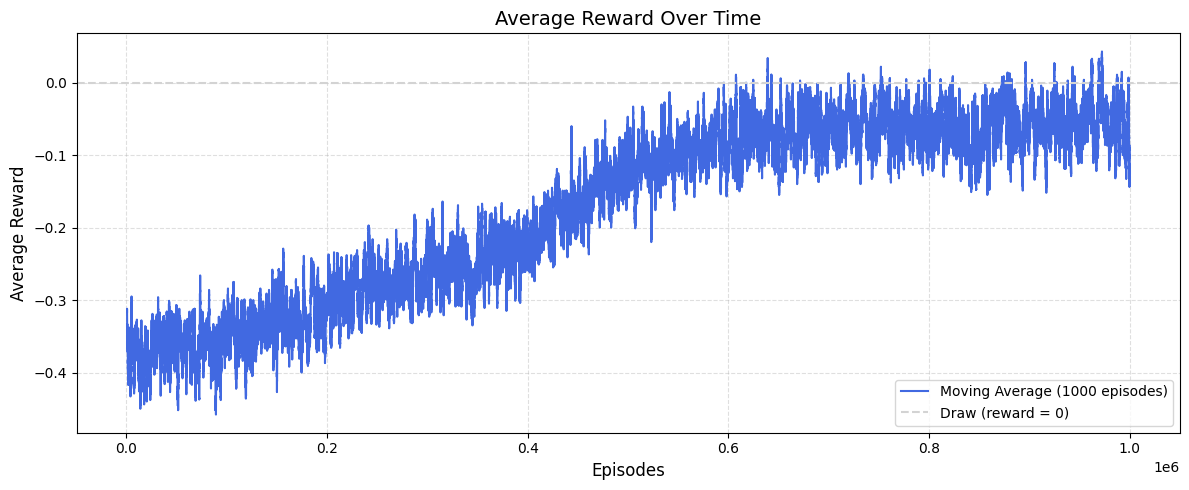

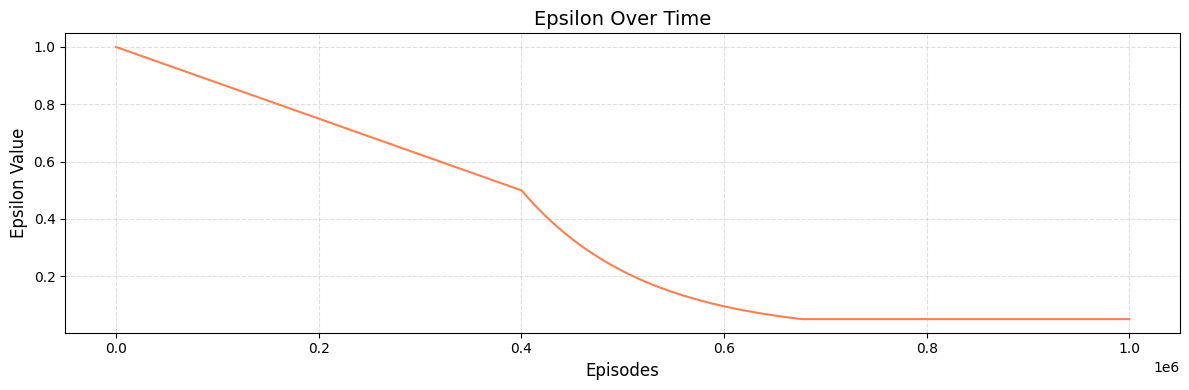

In [ ]:
plot_learning_diagnostics(
    episode_rewards=episode_rewards,
    epsilon_values=epsilon_values,
    window_size=1000
)

# Visualizing The Policy

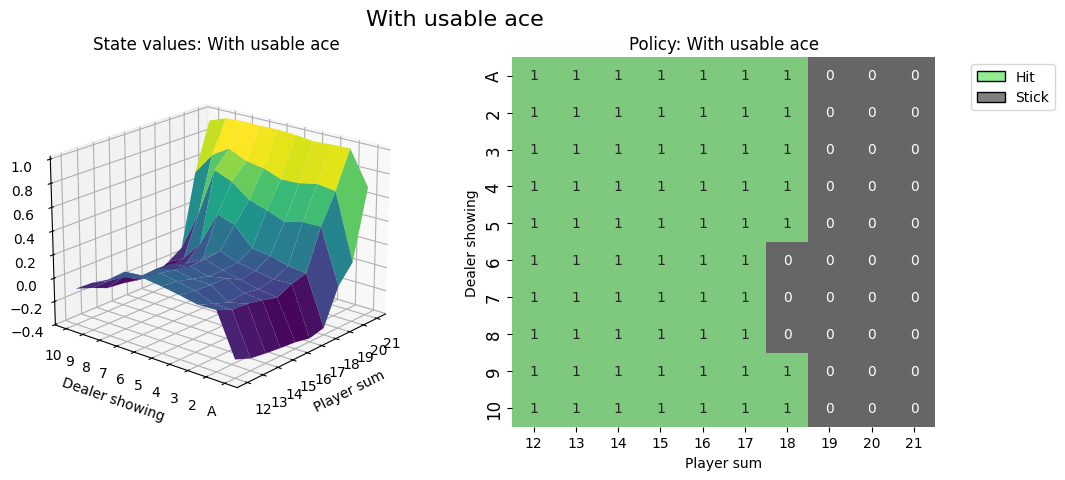

In [ ]:
def create_grids(agent, usable_ace=False):
    """Create value and policy grid given an agent."""
    # convert our state-action values to state values
    # and build a policy dictionary that maps observations to actions
    state_value = defaultdict(float)
    policy = defaultdict(int)
    for obs, action_values in agent.q_values.items():
        state_value[obs] = float(np.max(action_values))
        policy[obs] = int(np.argmax(action_values))

    player_count, dealer_count = np.meshgrid(
        # players count, dealers face-up card
        np.arange(12, 22),
        np.arange(1, 11),
    )

    # create the value grid for plotting
    value = np.apply_along_axis(
        lambda obs: state_value[(obs[0], obs[1], usable_ace)],
        axis=2,
        arr=np.dstack([player_count, dealer_count]),
    )
    value_grid = player_count, dealer_count, value

    # create the policy grid for plotting
    policy_grid = np.apply_along_axis(
        lambda obs: policy[(obs[0], obs[1], usable_ace)],
        axis=2,
        arr=np.dstack([player_count, dealer_count]),
    )
    return value_grid, policy_grid


def create_plots(value_grid, policy_grid, title: str):
    """Creates a plot using a value and policy grid."""
    # create a new figure with 2 subplots (left: state values, right: policy)
    player_count, dealer_count, value = value_grid
    fig = plt.figure(figsize=plt.figaspect(0.4))
    fig.suptitle(title, fontsize=16)

    # plot the state values
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.plot_surface(
        player_count,
        dealer_count,
        value,
        rstride=1,
        cstride=1,
        cmap="viridis",
        edgecolor="none",
    )
    plt.xticks(range(12, 22), range(12, 22))
    plt.yticks(range(1, 11), ["A"] + list(range(2, 11)))
    ax1.set_title(f"State values: {title}")
    ax1.set_xlabel("Player sum")
    ax1.set_ylabel("Dealer showing")
    ax1.zaxis.set_rotate_label(False)
    ax1.set_zlabel("Value", fontsize=14, rotation=90)
    ax1.view_init(20, 220)

    # plot the policy
    fig.add_subplot(1, 2, 2)
    ax2 = sns.heatmap(policy_grid, linewidth=0, annot=True, cmap="Accent_r", cbar=False)
    ax2.set_title(f"Policy: {title}")
    ax2.set_xlabel("Player sum")
    ax2.set_ylabel("Dealer showing")
    ax2.set_xticklabels(range(12, 22))
    ax2.set_yticklabels(["A"] + list(range(2, 11)), fontsize=12)

    # add a legend
    legend_elements = [
        Patch(facecolor="lightgreen", edgecolor="black", label="Hit"),
        Patch(facecolor="grey", edgecolor="black", label="Stick"),
    ]
    ax2.legend(handles=legend_elements, bbox_to_anchor=(1.3, 1))
    return fig


# state values & policy with usable ace (ace counts as 11)
value_grid, policy_grid = create_grids(agent, usable_ace=True)
fig1 = create_plots(value_grid, policy_grid, title="With usable ace")
plt.show()

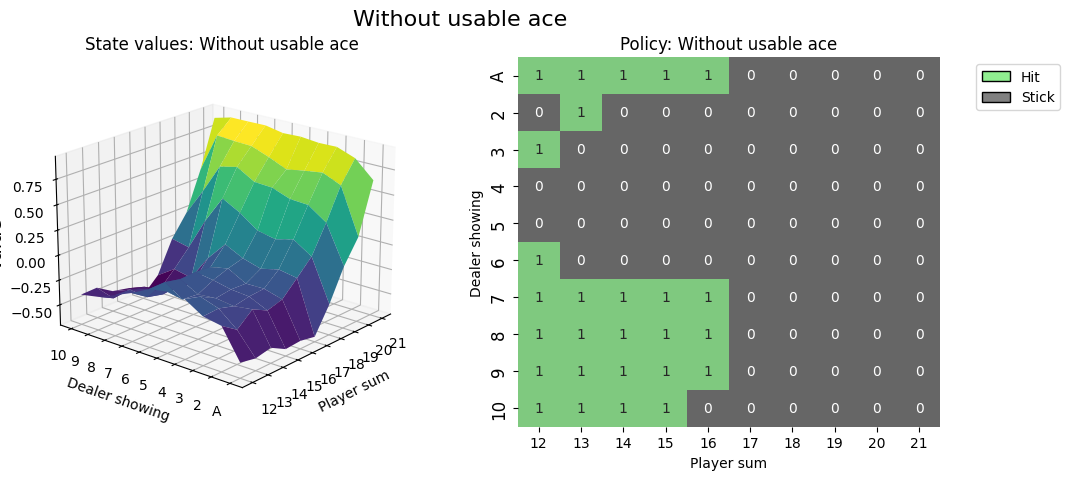

In [ ]:
# state values & policy without usable ace (ace counts as 1)
value_grid, policy_grid = create_grids(agent, usable_ace=False)
fig2 = create_plots(value_grid, policy_grid, title="Without usable ace")
plt.show()

# Test and Evaluation

Testing Decaying Epsilon-Greedy Policy: 100%|██████████| 10000/10000 [00:01<00:00, 5601.50it/s]


RESULTS
Wins       : 4366 (43.66%)
Draws      : 851 (8.51%)
Losses     : 4783 (47.83%)
Average Reward: -0.042
Consistency (Standard Deviation): 0.956


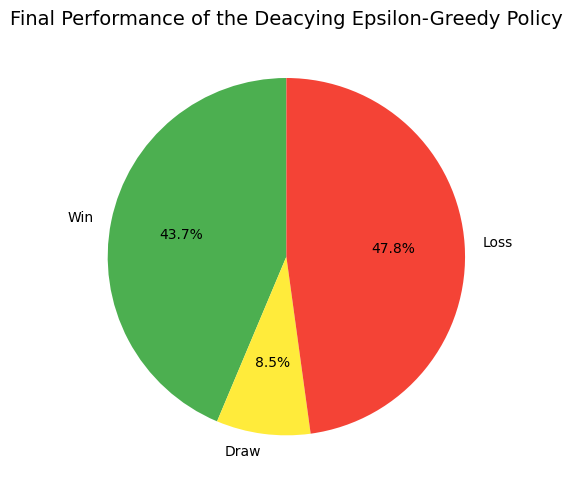

In [ ]:
# Initialize counters for results
wins = draws = losses = 0
total_reward = 0
test_episodes = 10000
episode_rewards = []

# Testing the decayng epsilon greedy policy
for _ in tqdm(range(test_episodes), desc="Testing Decaying Epsilon-Greedy Policy"):
    state, _ = env.reset()
    done = False
    reward_per_episode = 0


    while not done:
        action = int(np.argmax(agent.q_values[state]))  # Choose the best action based on Q-values
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        state = next_state
        total_reward += reward  # Accumulate total reward
        reward_per_episode += reward  # Accumulate reward for the episode

    episode_rewards.append(reward_per_episode)


    # Count the results
    if reward > 0:
        wins += 1
    elif reward == 0:
        draws += 1
    else:
        losses += 1

# Calculate evaluation metrics
win_rate = wins / test_episodes
average_reward = total_reward / test_episodes
consistency = np.std(episode_rewards)  # Standard deviation of rewards

# Print results
print("\nRESULTS")
print(f"Wins       : {wins} ({win_rate:.2%})")
print(f"Draws      : {draws} ({draws/test_episodes:.2%})")
print(f"Losses     : {losses} ({losses/test_episodes:.2%})")
print(f"Average Reward: {average_reward:.3f}")
print(f"Consistency (Standard Deviation): {consistency:.3f}")

# Prepare data for pie chart
test_results = (wins, draws, losses)
labels = ['Win', 'Draw', 'Loss']
sizes = [wins, draws, losses]
colors = ['#4CAF50', '#FFEB3B', '#F44336']

# Create pie chart
plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title("Final Performance of the Deacying Epsilon-Greedy Policy", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
env.close()